### Import libraries and modules

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import numpy as np
# import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from src.data.training_matrix import build_training_matrix
from src.models.quantile_model import train_quantile_models
from src.models.conformal import fit_conformal, predict_interval
from src.evaluation.metrics import coverage, sharpness, crps

### Load Data and build trainig matrix and split to 70% train, 10% calibration, 20% test

In [2]:
# Load X and y from training_matrix module from src
X, y = build_training_matrix()
# carve off the test set (last 20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
# carve off the calibration (last 12.5% of 80% is 10% of total)
X_train, X_cal, y_train, y_cal = train_test_split(X_temp, y_temp, test_size=0.125, shuffle=False)
# shapes of X_train, X_test, and X_cal
print(f"The sahapes of X_train is {X_train.shape}, X_test is {X_test.shape}, and X_cal is {X_cal.shape}")

The First 10 rows of the series `physics_pred` is: 
time
2022-01-01 00:00:00+00:00    0.0
2022-01-01 01:00:00+00:00    0.0
2022-01-01 02:00:00+00:00    0.0
2022-01-01 03:00:00+00:00    0.0
2022-01-01 04:00:00+00:00    0.0
Name: physics_pred, dtype: float64
The sahapes of X_train is (18395, 6), X_test is (5256, 6), and X_cal is (2628, 6)


### Train, calibrate, and predict

In [3]:
models = train_quantile_models(X_train, y_train)
print("Models trained:", list(models.keys()))

Models trained: ['q10', 'q50', 'q90']


### Compute q_hat from calibration set

In [4]:
q_hat_p90 = fit_conformal(models["q90"], X_cal, y_cal, alpha=0.9)
q_hat_p50 = fit_conformal(models["q50"], X_cal, y_cal, alpha=0.5)
print(f"q_hat_p50: {q_hat_p50:.1f} MW")
print(f"q_hat_p90: {q_hat_p90:.1f} MW")

q_hat_p50: 2.1 MW
q_hat_p90: 770.1 MW


### predict intervals on test set

In [5]:
intervals = predict_interval(models, q_hat_p50, q_hat_p90, X_test)
intervals

,p10,p50,p90
time,,,
2024-05-26 01:00:00+00:00,1.479682,5.177151,774.480446
2024-05-26 02:00:00+00:00,2.228080,6.753027,775.179185
2024-05-26 03:00:00+00:00,3.328123,129.372102,1090.215801
2024-05-26 04:00:00+00:00,1422.973755,1850.119027,2790.004131
2024-05-26 05:00:00+00:00,851.002808,2750.514657,4460.976666
...,...,...,...
2024-12-30 20:00:00+00:00,2.266762,5.311139,774.082584
2024-12-30 21:00:00+00:00,2.253689,5.311303,774.082584
2024-12-30 22:00:00+00:00,2.227644,5.312833,774.081168


### convert residual intervals to total solar MW

In [6]:
physics_test = X_test["physics_pred"]
intervals["p10_total"] = physics_test + intervals["p10"]
intervals["p50_total"] = physics_test + intervals["p50"]
intervals["p90_total"] = physics_test + intervals["p90"]
y_actual = y_test + physics_test
print(intervals.head())
print(f"Conformal correction q_hat_p50: {q_hat_p50:.1f} MW")
print(f"Conformal correction q_hat_p90: {q_hat_p90:.1f} MW")

                                   p10          p50          p90    p10_total  \
time                                                                            
2024-05-26 01:00:00+00:00     1.479682     5.177151   774.480446     1.479682   
2024-05-26 02:00:00+00:00     2.228080     6.753027   775.179185     2.228080   
2024-05-26 03:00:00+00:00     3.328123   129.372102  1090.215801     3.328123   
2024-05-26 04:00:00+00:00  1422.973755  1850.119027  2790.004131  2212.139741   
2024-05-26 05:00:00+00:00   851.002808  2750.514657  4460.976666  6114.661872   

                             p50_total    p90_total  
time                                                 
2024-05-26 01:00:00+00:00     5.177151   774.480446  
2024-05-26 02:00:00+00:00     6.753027   775.179185  
2024-05-26 03:00:00+00:00   129.372102  1090.215801  
2024-05-26 04:00:00+00:00  2639.285013  3579.170117  
2024-05-26 05:00:00+00:00  8014.173721  9724.635730  
Conformal correction q_hat_p50: 2.1 MW
Conformal corre

### Coverage check

In [7]:
cov_p10 = coverage(y_actual, lower=-np.inf, upper=intervals["p10_total"])
cov_p50 = coverage(y_actual, lower=-np.inf, upper=intervals["p50_total"])
cov_p90 = coverage(y_actual, lower=-np.inf, upper=intervals["p90_total"])

print(f"P10 coverage: {cov_p10:.3f}  (target: 0.10)")
print(f"P50 coverage: {cov_p50:.3f}  (target: 0.50)")
print(f"P90 coverage: {cov_p90:.3f}  (target: 0.90)")


P10 coverage: 0.036  (target: 0.10)
P50 coverage: 0.279  (target: 0.50)
P90 coverage: 0.869  (target: 0.90)


### Reliability Diagram

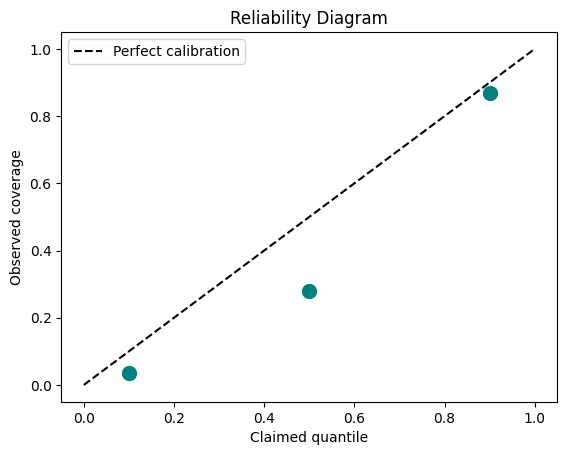

In [8]:
claimed   = [0.10, 0.50, 0.90]
observed  = [cov_p10, cov_p50, cov_p90]

fig, ax = plt.subplots()
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.scatter(claimed, observed, color="teal", s=100, zorder=5)
ax.set_xlabel("Claimed quantile")
ax.set_ylabel("Observed coverage")
ax.set_title("Reliability Diagram")
ax.legend()
plt.show()


### Limitation
P50 coverage = 0.28 (target: 0.50). 
**Root cause**: conformal exchangeability assumption is violated by seasonal distribution shift. Calibration set (Aug–Oct) and test set (Oct–Dec) have different solar patterns. 
*Fix*: rolling calibration window. P90 coverage is robust because upper-bound corrections are more transfer-stable across seasons.

### Sharpness and CRPS

In [9]:
# Sharpness (average interval width: smaller is better given good coverage)
sharp = sharpness(intervals["p10_total"], intervals["p90_total"])
print(f"Sharpness (avg interval width): {sharp:.1f} MW")

Sharpness (avg interval width): 3841.3 MW


In [10]:
# CRPS (needs a dict of arrays matching the key names your crps function expects ("q10", "q50", "q90")
quantile_preds = {
    "q10": intervals["p10_total"].values,
    "q50": intervals["p50_total"].values,
    "q90": intervals["p90_total"].values,
}
crps_score = crps(y_actual.values, quantile_preds)
print(f"CRPS: {crps_score:.1f} MW")


CRPS: 514.6 MW


### Summary
Here we were able to quantify the uncertainity in estimatation of total solar production. We got sharpness of 3842 MW and CRPS of 514.6 MW. Combined both can answer :on average, how far was the probability distribution from the truth? 

Interesting finding has been with P50 coverage = 0.28 (target: 0.50). Reson is actually much simpler and it is data distribution across the seasonal moths of the given year. Calibration set (Aug–Oct) and test set (Oct–Dec) have different solar patterns. 
However, P90 coverage is robust because upper-bound corrections are more transfer-stable across seasons.